# Binary Dependent Variables: LPM, Logit & Probit. Solutions
### Applied Statistical Data Analysis. Prof. Dr. Kristyna Ters | MSc Finance | FHNW
**Based on:** Brooks, C., *Introductory Econometrics for Finance*, Cambridge University Press, Ch. 12

Complete worked solutions for the ten exercises. Each solution shows the code, the numbers, and the interpretation you were expected to give.

---

## Step 0: Data Setup (run this first)

In [1]:
!pip install statsmodels --quiet

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.alpha':0.3, 'font.size':11
})

# ---- Dataset 1: the dividend cross-section, as in the lecture notebook ----
DIV_CSV = ('https://raw.githubusercontent.com/KristynaTers/ASDA/main/data/'
           'ASDA_DividendPayers_Teaching_2026.csv')
div = pd.read_csv(DIV_CSV, comment='#')
df = pd.DataFrame({'payer': div['payer'].astype(float), 'roa': div['roa_pct'],
                   'ln_mcap': np.log(div['mcap_usd_m']), 'leverage': div['leverage']})

# ---- Dataset 2: the corporate borrowers, as in the lecture notebook ----
BOR_CSV = ('https://raw.githubusercontent.com/KristynaTers/ASDA/main/data/'
           'ASDA_CorporateDefaults_Teaching_2026.csv')
bor = pd.read_csv(BOR_CSV, comment='#')
borrowers = pd.DataFrame({'default': bor['default'].astype(float),
                          'leverage': bor['leverage'], 'icr': bor['icr']})

print(f"df: {len(df)} stocks, payer share {df['payer'].mean():.1%}")
print(f"borrowers: {len(borrowers)} firms, default rate {borrowers['default'].mean():.1%}")

df: 500 stocks, payer share 62.0%
borrowers: 2000 firms, default rate 3.0%


## Exercise 1: The Benchmark Before Any Model
(a) Compute the unconditional payer share and the odds of paying in `df`.
(b) State the hit rate of the naive strategy "predict payer for every firm".
(c) One sentence: why is this number the benchmark every model must beat?

In [2]:
share = df['payer'].mean()
odds = share / (1 - share)
print(f"payer share: {share:.3f}")
print(f"odds of paying: {odds:.2f} to one")
print(f"naive hit rate: {share:.1%}")

payer share: 0.620
odds of paying: 1.63 to one
naive hit rate: 62.0%


**Interpretation.** (a) About 62 percent of firms pay; the odds are about 1.63 to one, i.e.
paying is 1.63 times as likely as not paying. (b) Predicting "payer" for everyone is right for
exactly the payers, so the naive hit rate equals the payer share. (c) A model that classifies no
better than the majority-class rule adds nothing; the confusion-table comparison in Exercise 10
is measured against exactly this number.

## Exercise 2: The Linear Probability Model
(a) Regress `payer` on `roa`, `ln_mcap` and `leverage` by OLS with White (HC1) robust standard
errors.
(b) How many fitted values lie outside [0, 1]? What is the range of the fitted values?
(c) Why are robust standard errors not optional here? (Hint: the error variance of a 0/1
outcome is p(1 minus p).)

In [3]:
X = sm.add_constant(df[['roa', 'ln_mcap', 'leverage']])
lpm = sm.OLS(df['payer'], X).fit(cov_type='HC1')
print(lpm.summary().tables[1])

fitted = lpm.fittedvalues
print(f"\noutside [0,1]: {((fitted > 1) | (fitted < 0)).sum()}"
      f"  (range {fitted.min():.3f} to {fitted.max():.3f})")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8838      0.114     -7.787      0.000      -1.106      -0.661
roa            0.0146      0.002      6.066      0.000       0.010       0.019
ln_mcap        0.1375      0.009     14.762      0.000       0.119       0.156
leverage      -0.3603      0.110     -3.287      0.001      -0.575      -0.145

outside [0,1]: 46  (range -0.078 to 1.350)


**Interpretation.** (a) Each LPM coefficient is a probability change per unit of x, identical
for every firm. (b) Several fitted values escape the [0, 1] band; the largest is 1.35 and the smallest minus 0.08,
and neither is a probability: that is defect one. (c) For a 0/1 outcome the error variance is p(1 minus p) and p varies
with x by construction, so heteroskedasticity is guaranteed, not incidental: the naive OLS
standard errors are wrong in a known way, hence White robust SEs as introduced in the
diagnostics video.

## Exercise 3: Logit and Probit, Fitted and Compared
(a) Fit a logit and a probit of `payer` on the three regressors.
(b) Build a table with both coefficient vectors and their ratio. Which rule of thumb do you
recognise?
(c) Which reading of the tables is safe without any further computation?

In [4]:
logit = sm.Logit(df['payer'], X).fit(disp=0)
probit = sm.Probit(df['payer'], X).fit(disp=0)
comp = pd.DataFrame({'logit': logit.params.round(3), 'probit': probit.params.round(3),
                     'ratio': (logit.params/probit.params).round(2)})
print(comp)
print(logit.summary().tables[1])

          logit  probit  ratio
const    -8.559  -4.850   1.76
roa       0.090   0.050   1.79
ln_mcap   0.845   0.480   1.76
leverage -2.070  -1.172   1.77
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.5585      0.965     -8.865      0.000     -10.451      -6.666
roa            0.0896      0.016      5.571      0.000       0.058       0.121
ln_mcap        0.8454      0.088      9.619      0.000       0.673       1.018
leverage      -2.0698      0.705     -2.937      0.003      -3.451      -0.689


**Interpretation.** (b) The ratio sits at about 1.77 for every coefficient: the logistic curve is
a stretched normal curve, and matching the two latent error variances predicts exactly this scale,
pi/sqrt(3) = 1.81. A second convention gives the 1.6 you may remember: equate the two marginal
effects at P = 0.5, which needs 0.3989/0.25 = 1.60. Both numbers are COEFFICIENT factors. What is
not rescaled are the marginal effects themselves: logit and probit AMEs on these data differ by
one to three percent. Same S-curve, different scale; conclusions never differ. (c) Signs and
significance: profitability and size raise the payer probability, leverage lowers it, and the
z-statistics (inference is asymptotic, hence z and not t) clear 1.96. Magnitudes on the
probability scale need Exercise 6.

## Exercise 4: The Odds Language
(a) Compute the odds factor e^beta for each logit coefficient.
(b) By how many percent does one additional ROA point change the odds of paying?
(c) By how many percent does a 10-percentage-point leverage increase change the odds? Compute
it correctly (two steps) and explain why exponentiating the raw leverage coefficient would be
wrong.

In [5]:
factors = np.exp(logit.params)
print(pd.DataFrame({'beta': logit.params.round(3), 'e^beta': factors.round(3)}))

b_roa = logit.params['roa']; b_lev = logit.params['leverage']
print(f"\nROA: odds factor {np.exp(b_roa):.3f}  (+{(np.exp(b_roa)-1)*100:.1f} percent per ROA point)")
print(f"leverage +10pp: factor {np.exp(b_lev*0.10):.3f}"
      f"  ({(np.exp(b_lev*0.10)-1)*100:.1f} percent on the odds)")
print(f"WRONG (raw beta): {np.exp(b_lev):.3f}, that answers a 100-point jump")

           beta  e^beta
const    -8.559   0.000
roa       0.090   1.094
ln_mcap   0.845   2.329
leverage -2.070   0.126

ROA: odds factor 1.094  (+9.4 percent per ROA point)
leverage +10pp: factor 0.813  (-18.7 percent on the odds)
WRONG (raw beta): 0.126, that answers a 100-point jump


**Interpretation.** In the logit, odds equal e^(x'beta) exactly, so each unit of a regressor
multiplies the odds by e^beta. (b) One ROA point raises the odds by roughly 9 to 10 percent.
(c) Two steps: coefficient times the change first (beta times 0.10), exponentiate second; the
odds fall by roughly a fifth. Exponentiating the raw coefficient answers a leverage jump from
0 to 1, i.e. 100 percentage points, and overstates the effect massively.

## Exercise 5: A Full Prediction, Two Ways
Firm Y has ROA 4, ln market cap 6.0 and leverage 0.5.
(a) Compute its linear index and payer probability from the fitted logit.
(b) Compute its odds directly as e^index and convert them back to a probability. Confirm both
routes agree.
(c) Sanity check: why must the probability come out below 0.5 here?

In [6]:
xY = np.array([1, 4, 6.0, 0.5])
index_Y = xY @ logit.params
pY = 1/(1 + np.exp(-index_Y))
oddsY = np.exp(index_Y)
print(f"index: {index_Y:.3f}")
print(f"probability via logistic CDF : {pY:.3f}")
print(f"odds e^index: {oddsY:.3f}  -> probability {oddsY/(1+oddsY):.3f}")

index: -4.162
probability via logistic CDF : 0.015
odds e^index: 0.016  -> probability 0.015


**Interpretation.** (a, b) Both routes give the same probability, about 1.5 percent (the index is minus 4.16);
odds = e^index and P = odds/(1 + odds) are the same model in two currencies, and the agreement
is a built-in check on the arithmetic. (c) The index is clearly negative (small firm, thin
profitability, high leverage), and a negative index always maps to a probability below 0.5; if
your number lands above 0.5, a sign was lost.

## Exercise 6: Average Marginal Effects
(a) Compute the AME of the logit with `get_margeff(at='overall')`.
(b) Interpret the ROA and leverage effects in percentage points (leverage per 10 points).
(c) Compare the AME with the LPM coefficients from Exercise 2. What do you conclude?

In [7]:
ame = logit.get_margeff(at='overall')
print(ame.summary())

comp = pd.DataFrame({'AME': ame.margeff.round(4),
                     'LPM': lpm.params.drop('const').round(4).values},
                    index=['roa', 'ln_mcap', 'leverage'])
print(comp)

        Logit Marginal Effects       
Dep. Variable:                  payer
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
roa            0.0141      0.002      6.288      0.000       0.010       0.018
ln_mcap        0.1328      0.008     15.863      0.000       0.116       0.149
leverage      -0.3252      0.107     -3.032      0.002      -0.535      -0.115
             AME     LPM
roa       0.0141  0.0146
ln_mcap   0.1328  0.1375
leverage -0.3252 -0.3603


**Interpretation.** (a, b) One additional ROA point raises the payer probability by about 1.4
percentage points on average (AME 0.0141); ten leverage points lower it by about 3.3 points (the
leverage AME is −0.325 per unit, so multiply by 0.10). These are probability-scale numbers, unlike the index-scale betas.
(c) The LPM coefficients sit close to the AME: that closeness is the precise sense in which the
LPM is a legitimate quick look, while logit/probit remain the tools for predictions and for
anything near the probability boundaries.

## Exercise 7: Effects Fade at the Edges
(a) Using the logit slope factor P(1 minus P), compute the marginal effect of ROA for firms at
P = 0.5, P = 0.62 and P = 0.9 (use the fitted ROA coefficient).
(b) Plot the slope factor as a function of P.
(c) Which LPM defect does this repair, and what is the economic intuition?

P = 0.50: slope 0.2500, ME of ROA 2.24 pp
P = 0.62: slope 0.2356, ME of ROA 2.11 pp
P = 0.90: slope 0.0900, ME of ROA 0.81 pp


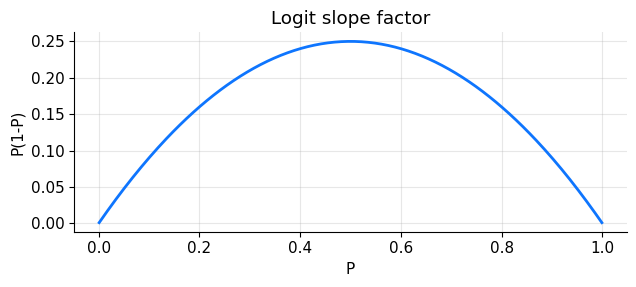

In [8]:
b_roa = logit.params['roa']
for p in [0.5, 0.62, 0.9]:
    print(f"P = {p:.2f}: slope {p*(1-p):.4f}, ME of ROA {b_roa*p*(1-p)*100:.2f} pp")

P = np.linspace(0.001, 0.999, 300)
plt.figure(figsize=(6.5, 3))
plt.plot(P, P*(1-P), color='#0E75FE', lw=2)
plt.xlabel('P'); plt.ylabel('P(1-P)'); plt.title('Logit slope factor')
plt.tight_layout(); plt.show()

**Interpretation.** (a) The same coefficient produces about 2.2 pp at the centre (2.3 pp with the
coefficient rounded to 0.09) but under 1 pp at P = 0.9: one coefficient, many effects, depending
on the position on the S-curve. (c) This
repairs defect three of the LPM (constant effects): near-certain payers and near-certain
non-payers barely react to one more ROA point, only borderline firms move a lot. The bell shape
of P(1 minus P), maximal at 0.5 and vanishing at the boundaries, encodes exactly that intuition.

## Exercise 8: Default Probabilities per Borrower
(a) Fit a probit of `default` on `leverage` and `icr` in the `borrowers` data.
(b) Compute the PD for borrower A (leverage 0.20, ICR 8), borrower B (leverage 0.65, ICR 1.5)
and borrower C (leverage 0.40, ICR 4).
(c) Rank the three and give the pricing implication in one sentence.

In [9]:
Xb = sm.add_constant(borrowers[['leverage', 'icr']])
pd_probit = sm.Probit(borrowers['default'], Xb).fit(disp=0)
print(pd_probit.summary().tables[1])

new = pd.DataFrame({'leverage': [0.20, 0.65, 0.40], 'icr': [8.0, 1.5, 4.0]}, index=['A', 'B', 'C'])
Xn = sm.add_constant(new, has_constant='add')
print("\nPD:", (pd_probit.predict(Xn)*100).round(1).to_dict())

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6495      0.223     -7.406      0.000      -2.086      -1.213
leverage       2.0003      0.501      3.990      0.000       1.018       2.983
icr           -0.1000      0.019     -5.298      0.000      -0.137      -0.063

PD: {'A': 2.0, 'B': 30.9, 'C': 10.6}


**Interpretation.** (b) The fitted probabilities land close to the slide values: about 2 percent
for A, about 30 percent for B, and roughly 10 percent for C in between. (c) B pays by far the
highest spread; the PD is the model's core output and feeds loan pricing, rating grades and
regulatory capital under the Basel internal-ratings approach. Note that the fitted coefficients
come out at the printed (minus 1.65, +2.0, minus 0.10): the teaching file was built that way, which
is what makes every number of this module reproducible. Note that n = 2000 keeps
the standard errors tight even though only about 3 percent of the firms default; the price of rare
events shows up in the cutoff analysis of Exercise 10, not in the standard errors.

## Exercise 9: McFadden's Pseudo-R-squared
(a) Report the log-likelihood of the fitted dividend logit and of its constant-only model, and
compute McFadden's pseudo-R-squared by hand from the two numbers. Confirm against `prsquared`.
(b) Why can this number never be negative for a model with regressors?
(c) Why is comparing it with an OLS R-squared of, say, 0.9 a mistake?

In [10]:
llf, ll0 = logit.llf, logit.llnull
mcf = 1 - llf/ll0
print(f"lnL fitted   : {llf:.1f}")
print(f"lnL constant : {ll0:.1f}")
print(f"McFadden by hand: {mcf:.3f}   (statsmodels: {logit.prsquared:.3f})")

lnL fitted   : -239.0
lnL constant : -332.0
McFadden by hand: 0.280   (statsmodels: 0.280)


**Interpretation.** (a) One minus the ratio of the two log-likelihoods. (b) The fitted model
nests the constant-only model, so its likelihood cannot be lower; the ratio is at most 1 and the
pseudo-R-squared at least 0. (c) It is a likelihood ratio in disguise, not a share of explained
variance; binary-model values are structurally smaller, 0.2 to 0.4 already marks a strong model,
and it should only be compared across models on the same data and the same y.

## Exercise 10: Confusion Tables and the Unbalanced-Sample Trap
(a) For the dividend logit, build the confusion table at cutoff 0.5, compute the hit rate and
compare with the naive benchmark. Report the two row rates (payers caught, non-payers caught).
(b) Repeat the cutoff-0.5 exercise for the PD probit. How many defaulters does it catch?
(c) Re-classify the borrowers with the cutoff set to the sample default rate and report
defaulters caught and false alarms. What is the lesson for credit scoring?

In [11]:
pred = (logit.predict(X) > 0.5).astype(int)
conf = pd.crosstab(df['payer'], pred, rownames=['actual'], colnames=['predicted'])
print(conf)
print(f"hit rate {(pred == df['payer']).mean():.1%}  vs naive {df['payer'].mean():.1%}")
print(f"payers caught {conf.loc[1,1]/conf.loc[1].sum():.1%},"
      f" non-payers caught {conf.loc[0,0]/conf.loc[0].sum():.1%}")

pb = pd_probit.predict(Xb)
pred05 = (pb > 0.5).astype(int)
caught = ((pred05 == 1) & (borrowers['default'] == 1)).sum()
print(f"\nPD sample, cutoff 0.5: predicted defaults {pred05.sum()},"
      f" defaulters caught {caught} of {int(borrowers['default'].sum())},"
      f" hit rate {(pred05 == borrowers['default']).mean():.1%}")

cut = borrowers['default'].mean()
predc = (pb > cut).astype(int)
caught_c = ((predc == 1) & (borrowers['default'] == 1)).sum()
false_c = ((predc == 1) & (borrowers['default'] == 0)).sum()
print(f"cutoff {cut:.3f}: defaulters caught {caught_c} of {int(borrowers['default'].sum())},"
      f" false alarms {false_c}")

predicted    0    1
actual             
0.0        125   65
1.0         45  265
hit rate 78.0%  vs naive 62.0%
payers caught 85.5%, non-payers caught 65.8%

PD sample, cutoff 0.5: predicted defaults 0, defaulters caught 0 of 60, hit rate 97.0%
cutoff 0.030: defaulters caught 44 of 60, false alarms 693


**Interpretation.** (a) The dividend model beats the 62 percent naive benchmark clearly, and the
two row rates show it catches payers more reliably than non-payers. (b) With a 3 percent event
rate, cutoff 0.5 predicts no defaults at all: the hit rate of 97 percent is exactly the naive
benchmark and every one of the 60 defaulters is missed, which is the unbalanced-sample trap. (c) Cutting at the sample share catches the
majority of defaulters at the price of many false alarms. The lesson: always compare against the
naive benchmark, always read the rows, and choose the cutoff from the cost ratio of the two
errors; in credit scoring a missed default costs the loan, a false alarm only a review.